In [1]:
# Setup
%load_ext autoreload
%autoreload 1
%aimport rectificacion, aruco

import os, glob, cv2 as cv
import numpy as np
import pickle
import open3d as o3d

DATA_DIR = "data"
CAPT_DIR = "data/captures"
RECT_DIR = "data/rectified"
TUNER_OUT = "data/pointcloud/tuner"
WORLD_OUT = "data/pointcloud/world_pnp"
os.makedirs(TUNER_OUT, exist_ok=True)
os.makedirs(WORLD_OUT, exist_ok=True)

with open(os.path.join(DATA_DIR, "stereo_maps.pkl"), "rb") as f:
    maps = pickle.load(f)
Q      = np.array(maps["Q"], dtype=np.float32)
P1     = np.array(maps.get("P1", maps.get("left_P")), dtype=np.float32)
K_rect = P1[:3, :3]

print("K_rect:\n", K_rect)
print("Q[3,2]=", float(Q[3,2]))



K_rect:
 [[604.2844    0.      966.26373]
 [  0.      604.2844  524.7561 ]
 [  0.        0.        1.     ]]
Q[3,2]= 16.66666603088379


# LIMPIEZA DE ARCHIVOS

In [2]:
import os, glob, shutil

# Directorios a limpiar
dirs_to_clean = {
    "data/pointcloud": "*.ply",           # Nubes individuales
    "data/pointcloud/world_pnp": "*.ply", # Nubes transformadas
}

print("=== LIMPIEZA DE ARCHIVOS ANTIGUOS ===\n")

for dir_path, pattern in dirs_to_clean.items():
    if not os.path.exists(dir_path):
        print(f"⚠️  {dir_path} no existe, salteando...")
        continue
    
    files = glob.glob(os.path.join(dir_path, pattern))
    
    if len(files) == 0:
        print(f"✓ {dir_path} ya está vacío")
    else:
        print(f"🗑️  Borrando {len(files)} archivos en {dir_path}/")
        for f in files:
            try:
                os.remove(f)
                print(f"   ✓ {os.path.basename(f)}")
            except Exception as e:
                print(f"   ✗ Error borrando {os.path.basename(f)}: {e}")
        print(f"   → Borrados {len(files)} archivos\n")

# Opcional: borrar también final_merged.ply si existe
merged = "data/pointcloud/final_merged.ply"
if os.path.exists(merged):
    os.remove(merged)
    print(f"🗑️  Borrado: {merged}")

print("\n✅ Limpieza completa. Ahora regenerá las nubes:")
print("   1. profundidad.calc_profundidad()")
print("   2. Loop de PnP con detect_pose_homography")
print("   3. Fusión final")

=== LIMPIEZA DE ARCHIVOS ANTIGUOS ===

✓ data/pointcloud ya está vacío
✓ data/pointcloud/world_pnp ya está vacío

✅ Limpieza completa. Ahora regenerá las nubes:
   1. profundidad.calc_profundidad()
   2. Loop de PnP con detect_pose_homography
   3. Fusión final


# RECTIFICACION

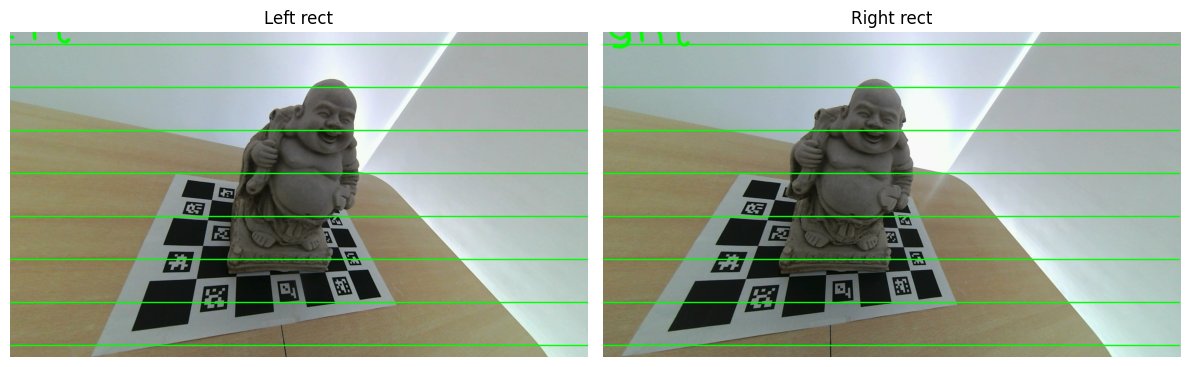

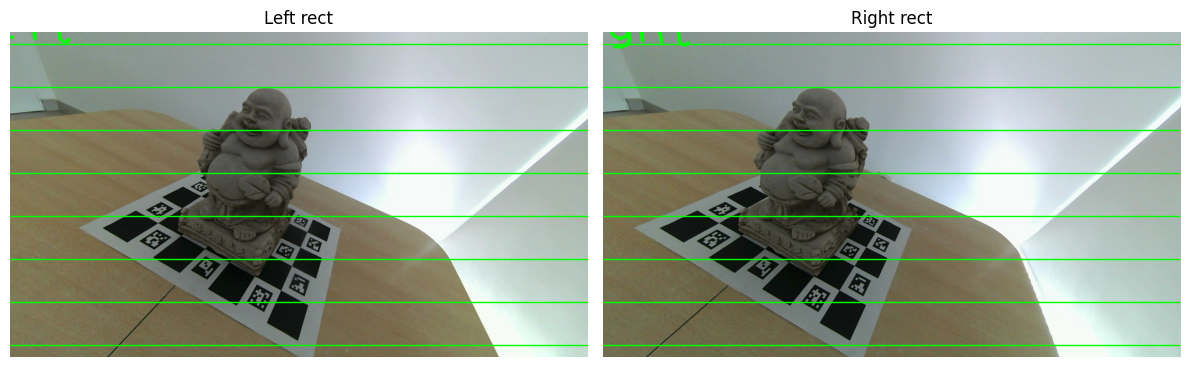

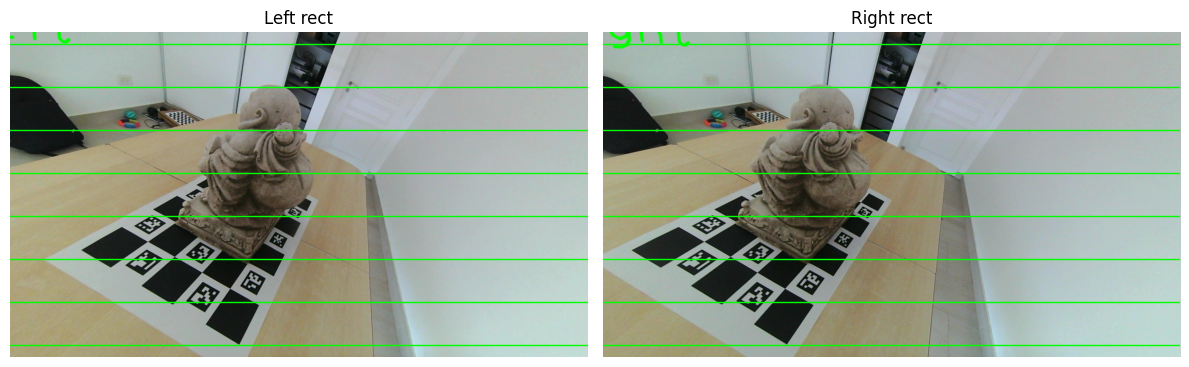

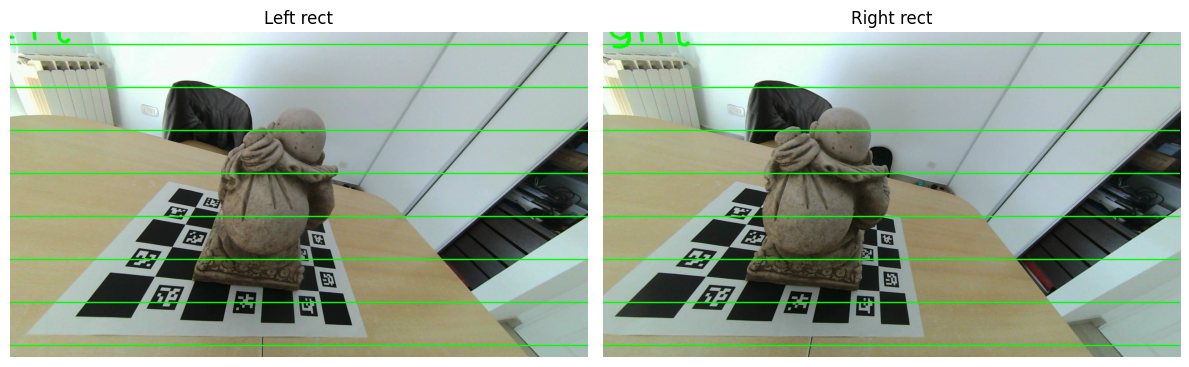

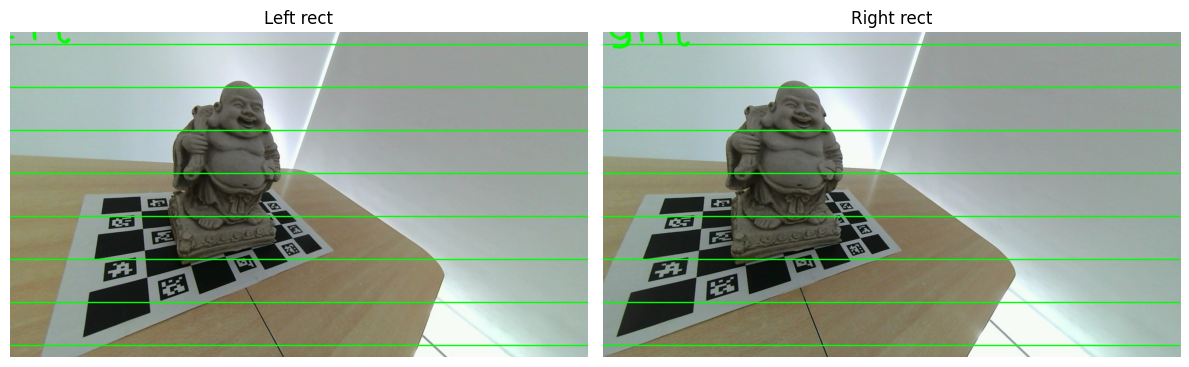

In [3]:
# Rectificación
import importlib, rectificacion
importlib.reload(rectificacion)

Q_from_rect, pares = rectificacion.rectificar_imagenes(
    data_dir=DATA_DIR,
    captures_dir=CAPT_DIR,
    out_dir=RECT_DIR,
    visualizar=True,
    n_muestras=5,
    n_lineas=8
)



# TUNER

In [4]:
# Tuner: sliders en ventana única
WIN = "Tuner"
cv.namedWindow(WIN, cv.WINDOW_NORMAL)
cv.resizeWindow(WIN, 900, 650)
cv.moveWindow(WIN, 100, 60)

def show_disparity(disp):
    disp_vis = cv.normalize(disp, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    disp_vis = cv.applyColorMap(disp_vis, cv.COLORMAP_TURBO)
    cv.imshow(WIN, disp_vis)
    return disp_vis

def nothing(_): pass
cv.createTrackbar("numDisp(x16)", WIN, 12, 64, nothing)
cv.createTrackbar("blockSize",    WIN, 7,  31, nothing)
cv.createTrackbar("preFilterCap", WIN, 31, 63, nothing)
cv.createTrackbar("uniqueness",   WIN, 10, 50, nothing)
cv.createTrackbar("speckleWinSz", WIN, 50, 200, nothing)
cv.createTrackbar("speckleRange", WIN, 32, 64,  nothing)
cv.createTrackbar("disp12MaxDiff",WIN, 1,  25,  nothing)
cv.createTrackbar("zMin(cm)",     WIN, 10, 500, nothing)
cv.createTrackbar("zMax(cm)",     WIN, 120, 1000, nothing)



In [5]:
# Tuner: loop interactivo → guarda *_disp.png y *_world.ply en TUNER_OUT
lefts  = sorted(glob.glob(os.path.join(RECT_DIR, "*left*_rect.png")))
rights = [p.replace("left", "right") for p in lefts]
pairs  = [(l, r) for l, r in zip(lefts, rights) if os.path.exists(r)]

print(f"Pares detectados: {len(pairs)}")
if not pairs:
    raise SystemExit("No se encontraron pares rectificados.")

idx = 0
while idx < len(pairs):
    Lp, Rp = pairs[idx]
    base   = os.path.splitext(os.path.basename(Lp))[0]
    print(f"\n→ {base}")

    L = cv.imread(Lp, cv.IMREAD_GRAYSCALE)
    R = cv.imread(Rp, cv.IMREAD_GRAYSCALE)
    if L is None or R is None:
        print("  ⚠️ No se pudo leer el par, saltando…")
        idx += 1
        continue

    while True:
        nd_mult16   = cv.getTrackbarPos("numDisp(x16)", WIN)
        numDisp     = max(1, nd_mult16) * 16
        bs          = cv.getTrackbarPos("blockSize", WIN)
        blockSize   = bs if bs % 2 == 1 else bs + 1
        preCap      = max(1, cv.getTrackbarPos("preFilterCap", WIN))
        uniq        = cv.getTrackbarPos("uniqueness", WIN)
        speckWin    = cv.getTrackbarPos("speckleWinSz", WIN)
        speckRange  = cv.getTrackbarPos("speckleRange", WIN)
        d12         = cv.getTrackbarPos("disp12MaxDiff", WIN)
        zmin_cm     = cv.getTrackbarPos("zMin(cm)", WIN)
        zmax_cm     = cv.getTrackbarPos("zMax(cm)", WIN)
        zmin, zmax  = zmin_cm/100.0, zmax_cm/100.0

        stereo = cv.StereoSGBM_create(
            minDisparity=0,
            numDisparities=numDisp,
            blockSize=blockSize,
            P1=8*1*blockSize*blockSize,
            P2=32*1*blockSize*blockSize,
            disp12MaxDiff=d12,
            preFilterCap=preCap,
            uniquenessRatio=uniq,
            speckleWindowSize=speckWin,
            speckleRange=speckRange,
            mode=cv.STEREO_SGBM_MODE_SGBM_3WAY
        )

        disp16 = stereo.compute(L, R).astype(np.int16)
        disp   = disp16.astype(np.float32) / 16.0
        disp_vis = show_disparity(disp)

        key = cv.waitKey(30) & 0xFF
        if key == 27:
            cv.destroyAllWindows(); raise SystemExit
        elif key == ord('n'):
            idx += 1; break
        elif key == ord('s'):
            cv.imwrite(os.path.join(TUNER_OUT, f"{base}_disp.png"), disp_vis)
            pts3d = cv.reprojectImageTo3D(disp, Q, handleMissingValues=True)
            mask = (disp > 0)
            Z = pts3d[...,2]
            mask &= (Z > zmin) & (Z < zmax)
            pts = pts3d[mask].reshape(-1,3)
            cols = cv.cvtColor(L, cv.COLOR_GRAY2BGR)[mask].reshape(-1,3) / 255.0
            if len(pts)==0:
                print("  ⚠️ nube vacía con estos parámetros."); continue
            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(pts.astype(np.float64))
            pcd.colors = o3d.utility.Vector3dVector(cols.astype(np.float64))
            out_ply = os.path.join(TUNER_OUT, f"{base}_world.ply")
            o3d.io.write_point_cloud(out_ply, pcd, write_ascii=False)
            print(f"  💾 guardado: {base}")
            # Vista rápida de la nube
            try:
                o3d.visualization.draw_geometries([pcd], window_name=f"Nube: {base}", width=1200, height=800)
            except Exception:
                try:
                    import plotly.graph_objects as go
                    pts_np = np.asarray(pcd.points)
                    idx = np.linspace(0, len(pts_np)-1, min(len(pts_np), 200_000)).astype(int)
                    xyz = pts_np[idx]
                    fig = go.Figure([go.Scatter3d(x=xyz[:,0], y=xyz[:,1], z=xyz[:,2], mode="markers",
                                                  marker=dict(size=1))])
                    fig.update_layout(scene=dict(aspectmode="data"), width=1200, height=800, title=f"Nube: {base}")
                    fig.show()
                    print("  (Viewer nativo no disponible; usando visor web)")
                except Exception:
                    print(f"  ⚠️ No pude abrir visor; abrí el PLY: {out_ply}")

print("\n✅ Listo. N: siguiente | S: guardar | ESC: salir")



Pares detectados: 21

→ 001_left_0_rect


  💾 guardado: 001_left_0_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
  💾 guardado: 001_left_0_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
  💾 guardado: 001_left_0_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
  💾 guardado: 001_left_0_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display

→ 002_left_1_rect
  💾 guardado: 002_left_1_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display

→ 003_left_10_rect
  💾 guardado: 003_left_10_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
  💾 guardado: 003_left_10_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display

→ 004_left_11_rect
  💾 guardado: 004_left_11_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
  💾 guardado: 004_left_11_rect
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service 

# UNA NUBE

In [6]:
# Visualizar UNA nube (sin T)
import numpy as np
one = sorted(glob.glob(os.path.join(TUNER_OUT, "*_world.ply")))
assert one, "No hay nubes en TUNER_OUT; corré el tuner y guardá alguna."
pcd = o3d.io.read_point_cloud(one[0])
pts = np.asarray(pcd.points)
print(f"N puntos: {len(pts)} | Z: [{pts[:,2].min():.3f}, {pts[:,2].max():.3f}]")
try:
    o3d.visualization.draw_geometries([pcd], window_name="Una nube", width=1200, height=800)
except Exception as e:
    print("Viewer no disponible:", e)



N puntos: 526144 | Z: [0.190, 0.360]
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display


# MERGE

In [ ]:
# Visualizar TODAS las nubes guardadas (merge + filtros)
plys = sorted(glob.glob(os.path.join(TUNER_OUT, "*_world.ply")))
assert plys, "No hay nubes guardadas por el tuner."

merged = o3d.geometry.PointCloud()
for p in plys:
    merged += o3d.io.read_point_cloud(p)

# Downsample y limpieza (ajustable)
merged = merged.voxel_down_sample(0.008)
merged, _ = merged.remove_statistical_outlier(nb_neighbors=15, std_ratio=1.3)

o3d.io.write_point_cloud(os.path.join(DATA_DIR, "pointcloud", "final_merged.ply"), merged, write_ascii=False)
print("final_merged.ply guardado.")
try:
    o3d.visualization.draw_geometries([merged], window_name="Reconstrucción 3D", width=1400, height=900)
except Exception as e:
    print("Viewer no disponible:", e)

